Dataset Estimation of Obesity Levels sesuai untuk clustering karena memiliki berbagai fitur numerik seperti Age, Height, Weight, FCVC, NCP, CH2O, FAF, dan TUE yang menggambarkan kondisi fisik dan kebiasaan individu. Fitur-fitur tersebut dapat digunakan untuk mengelompokkan individu berdasarkan kemiripan karakteristik, sehingga cocok dianalisis menggunakan metode K-Means.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import joblib

In [3]:
file_path = "ObesityDataSet_raw_and_data_sinthetic.csv"

df = pd.read_csv(file_path)

df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.shape

(2111, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [6]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [7]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [8]:
df.duplicated().sum()

np.int64(24)

In [9]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [10]:
features = [
    'Age',
    'Height',
    'Weight',
    'FCVC',
    'NCP',
    'CH2O',
    'FAF',
    'TUE'
]

X = df[features]

X.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0


In [11]:
X.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape data setelah standarisasi:", X_scaled.shape)

Shape data setelah standarisasi: (2111, 8)


In [13]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

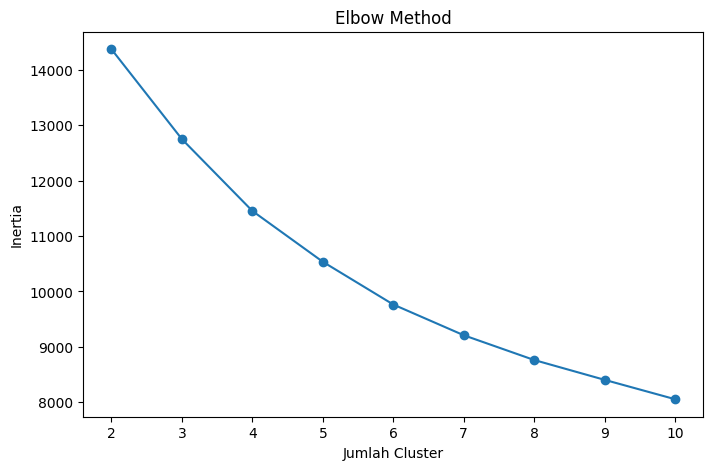

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Grafik Elbow Method menunjukkan penurunan inertia yang cukup besar hingga K = 4, kemudian mulai melandai. Oleh karena itu, K = 4 dapat menjadi pilihan cluster yang cukup optimal berdasarkan Elbow Method.

In [15]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

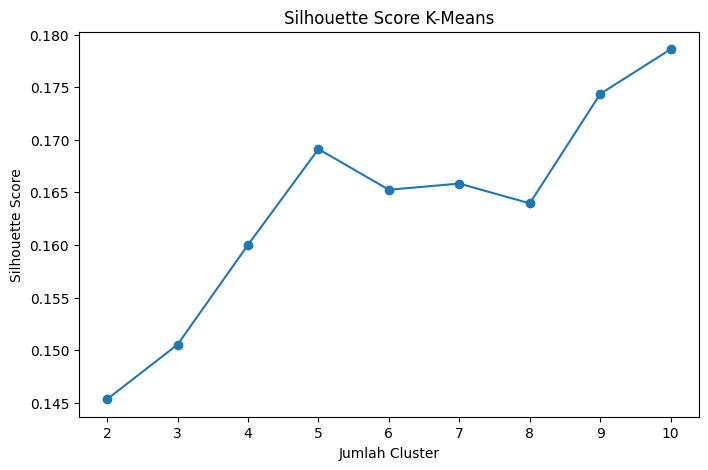

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score K-Means")

plt.show()

Grafik Silhouette Score menunjukkan bahwa K = 10 memiliki nilai tertinggi, sekitar 0,1786. Jadi, berdasarkan Silhouette Score, 10 cluster merupakan pilihan terbaik, meskipun kualitas pemisahan clusternya masih kurang optimal.

In [17]:
best_k = range(2, 11)[
    silhouette_scores.index(
        max(silhouette_scores)
    )
]

print("Jumlah cluster terbaik:", best_k)
print("Silhouette Score:", max(silhouette_scores))

Jumlah cluster terbaik: 10
Silhouette Score: 0.17861126871188154


In [18]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

df["KMeans_Cluster"].value_counts().sort_index()

,count
KMeans_Cluster,
0,139
1,312
2,209
3,153
4,227
5,222
6,166
7,226
8,210


In [19]:
cluster_profile = df.groupby(
    "KMeans_Cluster"
)[features].mean().round(2)

cluster_profile

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
KMeans_Cluster,,,,,,,,
0,21.07,1.67,81.56,2.34,1.24,1.87,0.67,1.41
1,25.84,1.79,103.77,1.98,2.85,2.20,0.90,0.42
2,25.49,1.65,105.73,2.98,3.00,2.21,0.11,0.49
3,20.87,1.73,73.58,2.04,3.04,2.35,2.20,1.48
4,37.77,1.66,85.11,2.43,2.52,1.72,0.88,0.20
5,21.08,1.63,64.09,2.50,3.10,1.73,0.93,0.30
6,22.27,1.60,63.61,2.37,1.14,1.96,0.67,0.17
7,20.95,1.68,69.33,1.85,3.02,1.58,0.53,1.27
8,20.63,1.76,67.91,2.80,3.18,2.22,2.04,0.55


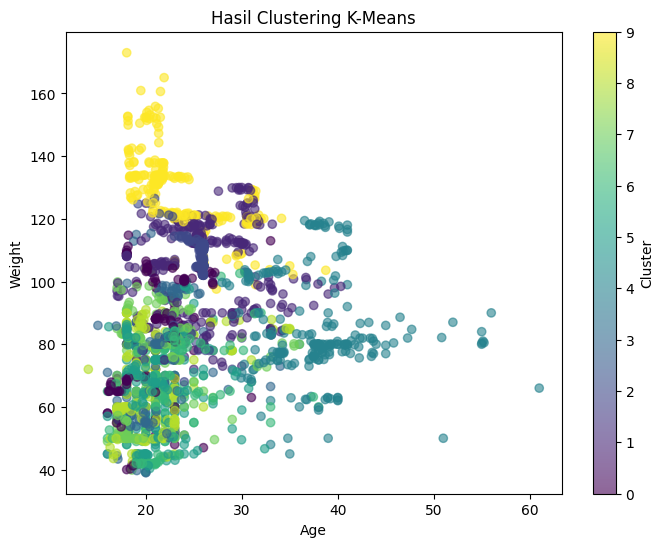

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Age"],
    df["Weight"],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Weight")
plt.title("Hasil Clustering K-Means")

plt.colorbar(
    label="Cluster"
)

plt.show()

Grafik menunjukkan hasil K-Means dengan 10 cluster (Cluster 0–9) berdasarkan Age dan Weight. Setiap warna mewakili cluster yang berbeda, tetapi beberapa cluster masih terlihat saling berdekatan, sehingga pemisahan antar-cluster belum terlalu jelas.

In [21]:
final_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

davies_bouldin = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", final_silhouette)
print("Davies-Bouldin Index:", davies_bouldin)

Silhouette Score: 0.17861126871188154
Davies-Bouldin Index: 1.6673760120037442


Hasil evaluasi menunjukkan bahwa clustering masih belum optimal. Silhouette Score sebesar 0.1786 menunjukkan pemisahan antar-cluster masih kurang jelas, sedangkan Davies-Bouldin Index sebesar 1.6674 menunjukkan masih terdapat kemiripan antar-cluster.

In [22]:
joblib.dump(
    scaler,
    "scaler_obesity.joblib"
)

['scaler_obesity.joblib']

In [23]:
joblib.dump(
    kmeans,
    "kmeans_obesity.joblib"
)

['kmeans_obesity.joblib']

In [24]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import joblib

@st.cache_resource
def load_artefak():
    scaler = joblib.load("scaler_obesity.joblib")
    model_kmeans = joblib.load("kmeans_obesity.joblib")
    return scaler, model_kmeans

scaler, model_kmeans = load_artefak()

st.title("🧍 Segmentasi Individu dengan K-Means")
st.write("Aplikasi untuk memprediksi cluster berdasarkan kondisi fisik dan kebiasaan.")

st.markdown("---")

col1, col2 = st.columns(2)

with col1:
    age = st.number_input("Age", value=25.0)
    height = st.number_input("Height", value=1.70)
    weight = st.number_input("Weight", value=70.0)
    fcvc = st.number_input("FCVC", value=2.0)

with col2:
    ncp = st.number_input("NCP", value=3.0)
    ch2o = st.number_input("CH2O", value=2.0)
    faf = st.number_input("FAF", value=1.0)
    tue = st.number_input("TUE", value=1.0)

if st.button("Prediksi Cluster"):

    input_data = pd.DataFrame(
        [[
            age,
            height,
            weight,
            fcvc,
            ncp,
            ch2o,
            faf,
            tue
        ]],
        columns=[
            "Age",
            "Height",
            "Weight",
            "FCVC",
            "NCP",
            "CH2O",
            "FAF",
            "TUE"
        ]
    )

    scaled_input = scaler.transform(input_data)

    cluster_result = model_kmeans.predict(
        scaled_input
    )[0]

    st.success(
        f"Individu ini masuk ke dalam: **Cluster {cluster_result}**"
    )

    st.metric(
        label="Status Prediksi",
        value="Berhasil",
        delta="Selesai"
    )
'''

with open("streamlit.py", "w") as f:
    f.write(streamlit_code)

print("streamlit.py berhasil dibuat.")

streamlit.py berhasil dibuat.


In [25]:
requirements = """streamlit
pandas
scikit-learn
joblib
numpy
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt berhasil dibuat.")

requirements.txt berhasil dibuat.
